# Analysis of Evaluation Results

Prepare metrics dataframes.

In [2]:
import pandas as pd

ctgan_eval = pd.read_csv("metrics_results/ctgan_eval.csv", index_col=0)
rtvae_eval = pd.read_csv("metrics_results/rtvae_eval.csv", index_col=0)
ddpm_eval = pd.read_csv("metrics_results/ddpm_eval.csv", index_col=0)
nflow_eval = pd.read_csv("metrics_results/nflow_eval.csv", index_col=0)
bayesian_network_eval = pd.read_csv("metrics_results/bayesian_network_eval.csv", index_col=0)

In [3]:
models = {
    "CTGAN": ctgan_eval,
    "RTVAE": rtvae_eval,
    "DDPM": ddpm_eval,
    "NF": nflow_eval,
    "BN": bayesian_network_eval,
}

In [4]:
import matplotlib.pyplot as plt

In [5]:
def plot_metric_bar(metric, models, figsize=(6, 4), fmt="{:.4f}"):
    values = [df.loc[metric, "mean"] for df in models.values()]
    labels = list(models.keys())

    plt.figure(figsize=figsize)
    bars = plt.bar(labels, values)
    plt.title(metric)

    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            fmt.format(val),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

## Fidelity / Statistical Similarity

In [6]:
fidelity_metrics = [
    "stats.jensenshannon_dist.marginal",
    "stats.max_mean_discrepancy.joint",
    "stats.wasserstein_dist.joint",
    "stats.prdc.precision",
    "stats.prdc.recall",
]

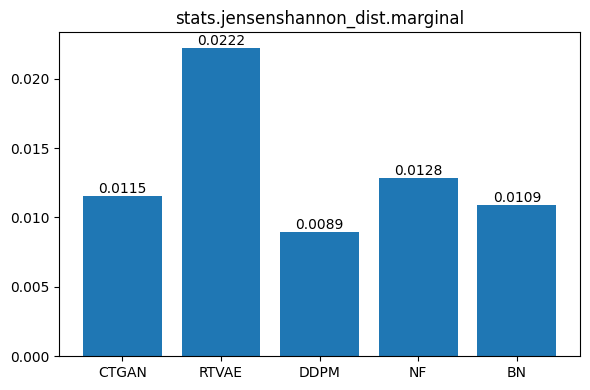

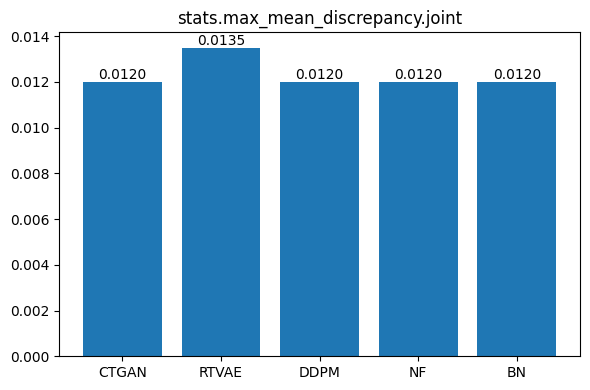

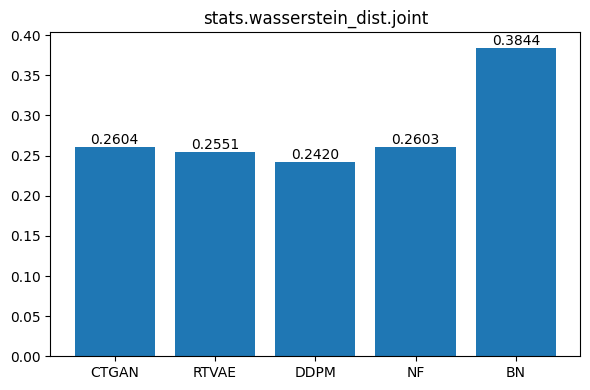

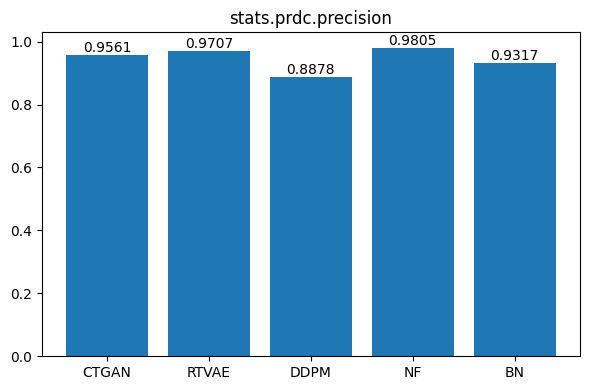

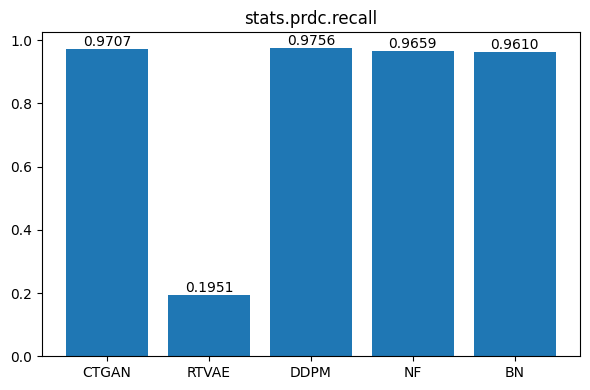

In [7]:
for metric in fidelity_metrics:
    plot_metric_bar(metric, models)

## Utility / Performance

In [8]:
performance_metrics = [
    "performance.xgb.gt",
    "performance.xgb.syn_id",
    "performance.xgb.syn_ood",
]

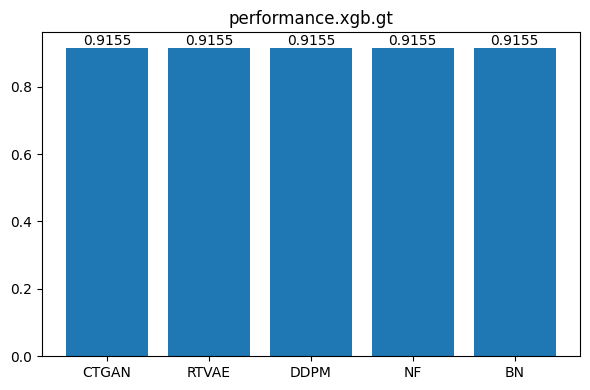

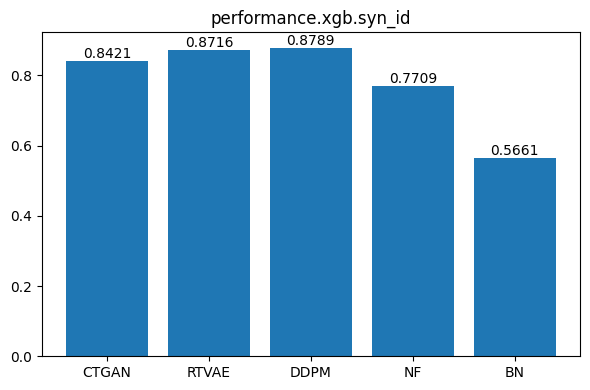

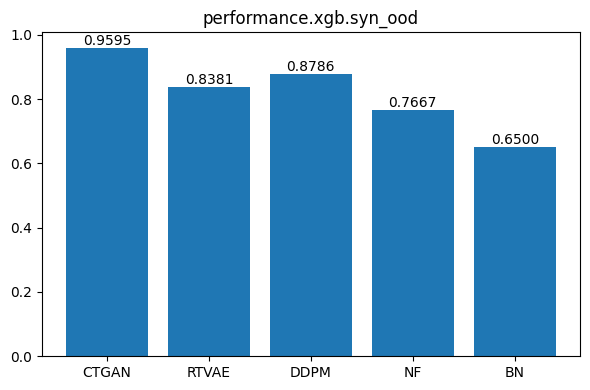

In [9]:
for metric in performance_metrics:
    plot_metric_bar(metric, models)

## Detection

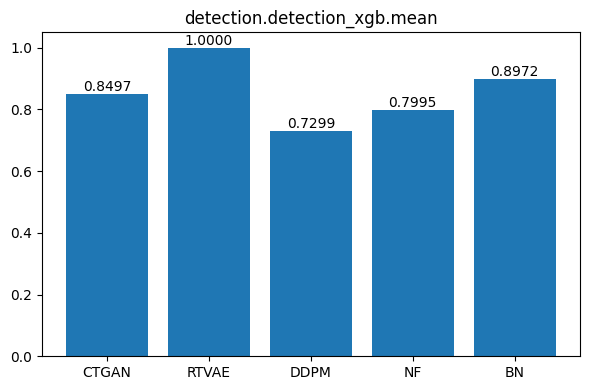

In [10]:
plot_metric_bar("detection.detection_xgb.mean", models)

## Privacy

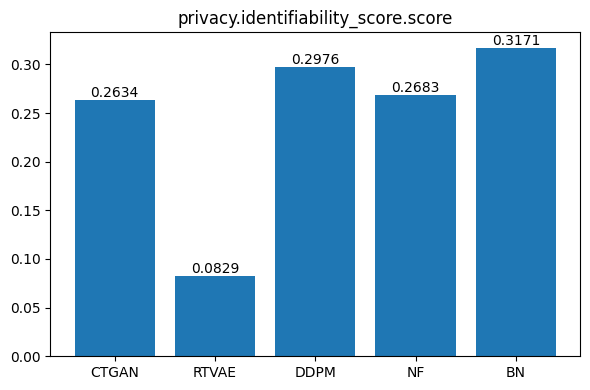

In [12]:
plot_metric_bar("privacy.identifiability_score.score", models)

## Sanity

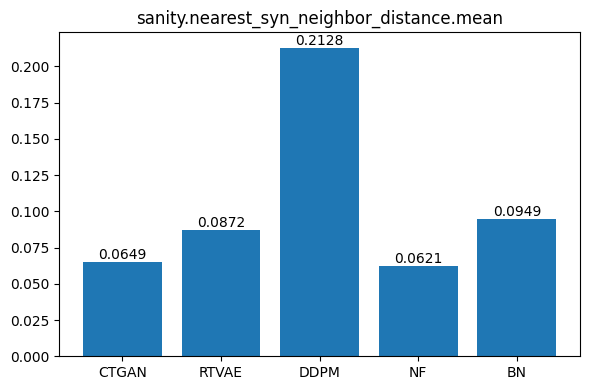

In [13]:
plot_metric_bar("sanity.nearest_syn_neighbor_distance.mean", models)